In [ ]:
import numpy as np
import matplotlib.pyplot as plt  
from sklearn.preprocessing import LabelEncoder

c:\Users\fpaul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.sparse import csr_matrix, issparse


In [2]:
iris = np.loadtxt("iris.csv", delimiter=",", skiprows=1, usecols=(0,1,2,3, 4), dtype=str)
le = LabelEncoder() 

In [3]:
X = iris[:, :4].astype(float)  
y = iris[:, 4]        
y = le.fit_transform(y)         

In [4]:
def separa_dados(X, y, treino=0.8, seed=42):
    if seed is not None:
        np.random.seed(seed)  

    n = X.shape[0]

    indices = np.random.permutation(n)

    split = int(n * treino)

    train_idx = indices[:split]
    test_idx = indices[split:]

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [5]:
X_train, X_test, y_train, y_test = separa_dados(X, y)

### Fórmula principal (Softmax)
$$
\begin{aligned}
P(y=k∣x) = \frac{e^{w^{T}_{x}k}}{\sum^{K}_{j=1}e^{T}_{j}k}
\end{aligned}
$$

### Intuição
$$
\begin{aligned}
z_{k} = w^{T}_{k}x
\end{aligned}
$$

### Função de custo (Cross-Entropy)
$$
\begin{aligned}
J(W) = -\sum^{N}_{i=1}\sum^{K}_{k=1}y_{ik}log P(y=k∣x_{i})
\end{aligned}
$$

### Forma vetorizada
$$
P=softmax(XW)
$$

In [ ]:
class LogisticRegressionMulticlass:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def __softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True) 
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def __one_hot(self, y, num_classes):
        one_hot = np.zeros((len(y), num_classes))
        one_hot[np.arange(len(y)), y] = 1
        return one_hot

    def __compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

    def fit(self, X, y):
        m, n = X.shape
        self.classes = len(np.unique(y))

        self.W = np.zeros((n, self.classes))
        self.b = np.zeros((1, self.classes))

        y_onehot = self.__one_hot(y, self.classes)

        for epoch in range(self.epochs):

            z = X @ self.W + self.b
            y_pred = self.__softmax(z)

            loss = self.__compute_loss(y_onehot, y_pred)

            dz = (y_pred - y_onehot) / m
            dW = X.T @ dz
            db = np.sum(dz, axis=0, keepdims=True)

            self.W -= self.lr * dW
            self.b -= self.lr * db

            if epoch % 100 == 0:
                print(f"Epoch {epoch} - Loss: {loss:.4f}")

    def predict(self, X):
        z = X @ self.W + self.b
        y_pred = self.__softmax(z)
        return np.argmax(y_pred, axis=1)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [12]:
lrm = LogisticRegressionMulticlass(lr=0.1, epochs=1000)
lrm.fit(X_train, y_train)

Epoch 0 - Loss: 1.0986
Epoch 100 - Loss: 0.4215
Epoch 200 - Loss: 0.2671
Epoch 300 - Loss: 0.2254
Epoch 400 - Loss: 0.1987
Epoch 500 - Loss: 0.1801
Epoch 600 - Loss: 0.1663
Epoch 700 - Loss: 0.1556
Epoch 800 - Loss: 0.1471
Epoch 900 - Loss: 0.1401


In [13]:
lrm.predict(X_test)

array([1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 1, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1,
       2, 2, 0, 1, 2, 0, 1, 2])

In [14]:
lrm.score(X_test, y_test)

np.float64(0.9666666666666667)

In [25]:
def plot_accuracy(model, X_train, y_train, X_test, y_test):
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    plt.bar(['Train', 'Test'], [train_acc, test_acc], color=['blue', 'orange'])
    plt.ylim(0, 1)
    plt.ylabel('Accuracy')
    plt.title('Model Accuracy')
    plt.show()

In [26]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')
    plt.show()

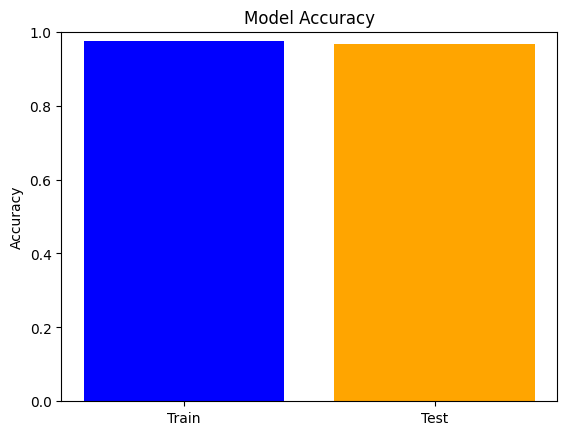

In [28]:
plot_accuracy(lrm, X_train, y_train, X_test, y_test)